# Proyecto Final
# Telecomunicaciones: Identificar operadores ineficaces

#  Telefonía virtual "CallMeMaybe"

1. INTRODUCCIÓN

El servicio de telefonía virtual CallMeMaybe está desarrollando una nueva función que brindará a los supervisores y las supervisores información sobre los operadores menos eficaces. Se considera que un operador es ineficaz si tiene una gran cantidad de llamadas entrantes perdidas (internas y externas) y un tiempo de espera prolongado para las llamadas entrantes. Además, si se supone que un operador debe realizar llamadas salientes, un número reducido de ellas también será un signo de ineficacia.

Lleva a cabo el análisis exploratorio de datos
Identificar operadores ineficaces
Prueba las hipótesis estadísticas


2. DESCRIPCIÓN DE LOS DATOS 

Los datasets contienen información sobre el uso del servicio de telefonía virtual CallMeMaybe. Sus clientes son organizaciones que necesitan distribuir gran cantidad de llamadas entrantes entre varios operadores, o realizar llamadas salientes a través de sus operadores. Los operadores también pueden realizar llamadas internas para comunicarse entre ellos. Estas llamadas se realizan a través de la red de CallMeMaybe.

El dataset comprimido telecom_dataset_us.csv contiene las siguientes columnas:

'user_id': ID de la cuenta de cliente
'date': fecha en la que se recuperaron las estadísticas
'direction': dirección" de llamada ('out' para saliente, 'in' para entrante)
'internal': si la llamada fue interna (entre los operadores de un cliente o clienta)
'operator_id': identificador del operador
'is_missed_call': si fue una llamada perdida
'calls_count': número de llamadas
'call_duration': duración de la llamada (sin incluir el tiempo de espera)
'total_call_duration': duración de la llamada (incluido el tiempo de espera)
El conjunto de datos telecom_clients_us.csv tiene las siguientes columnas:

'user_id': ID de usuario/a
'tariff_plan': tarifa actual de la clientela
'date_start': fecha de registro de la clientela


3. INICIALIZACIÓN

In [53]:
# Cargar las librerias necesarias 

# Librerías básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import datetime as dt
import math as mth

# Pruebas estadísticas
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import mannwhitneyu

In [54]:
# Cargar los archivos de datos en DataFrame
calls_df = pd.read_csv('telecom_dataset_new.csv', sep=',')
clients_df = pd.read_csv('telecom_clients.csv', sep=',')

In [55]:
# Imprimir la información general y resumida de sobre los datos de las llamadas 
print("* calls_df *")
print(calls_df.info())
print(calls_df.describe(include='all'))

* calls_df *
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB
None
              user_id                       date direction internal  \
count    53902.000000                      53902     53902    53785   
unique            NaN                        119         2        2   
top               NaN  2019-11-25 00:00:

In [56]:
# Se imprime una muestra de los datos de los clientes 
clients_df.head(10)

,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16
5,167764,A,2019-09-30
6,167050,A,2019-08-29
7,168252,A,2019-10-17
8,168495,A,2019-10-28
9,167879,A,2019-10-03


3.1 PREPARACIÓN DE LOS DATOS 

In [57]:
# Se transforman las columnas de fecha 
calls_df['date'] = pd.to_datetime(calls_df['date'])
clients_df['date_start'] = pd.to_datetime(clients_df['date_start'])

In [58]:
# Calculamos tiempo de espera con 'waiting_time'
calls_df['waiting_time'] = calls_df['total_call_duration'] - calls_df['call_duration']

In [59]:
# Revisamos llamdas internas 
calls_df['internal'] = calls_df['internal'].astype(bool)

In [60]:
# Preparamos agregados por operador 
operator_stats = calls_df.groupby('operator_id').agg(
    total_calls=('calls_count', 'sum'),
    total_missed_calls=('is_missed_call', 'sum'),
    avg_waiting_time=('waiting_time', 'mean'),
    total_out_calls=('calls_count', lambda x: x[calls_df.loc[x.index, 'direction']=='out'].sum()),
    total_in_calls=('calls_count', lambda x: x[calls_df.loc[x.index, 'direction']=='in'].sum())
).reset_index()

# Tasa de llamadas perdidas por operador
operator_stats['missed_call_rate'] = operator_stats['total_missed_calls'] / operator_stats['total_calls']

operator_stats.head()

,operator_id,total_calls,total_missed_calls,avg_waiting_time,total_out_calls,total_in_calls,missed_call_rate
0,879896.0,1131,50,110.671875,1071,60,0.044209
1,879898.0,7974,100,450.087649,7856,118,0.012541
2,880020.0,54,7,15.181818,46,8,0.129630
3,880022.0,219,33,57.565789,211,8,0.150685
4,880026.0,2439,94,121.171717,2414,25,0.038540


3.2 ANÁLISIS EXPLORATORIO DE LOS DATOS (EDA)

In [61]:
# Estadísticas descriptivas
display(calls_df.describe())

# Comprobamos nuevamente valores nulos
print("\nValores nulos por columna:")
print(calls_df.isna().sum())

,user_id,operator_id,calls_count,call_duration,total_call_duration,waiting_time
count,53902.000000,45730.000000,53902.000000,53902.000000,53902.000000,53902.000000
mean,167295.344477,916535.993002,16.451245,866.684427,1157.133297,290.448870
std,598.883775,21254.123136,62.917170,3731.791202,4403.468763,1127.905654
min,166377.000000,879896.000000,1.000000,0.000000,0.000000,0.000000
25%,166782.000000,900788.000000,1.000000,0.000000,47.000000,17.000000
50%,167162.000000,913938.000000,4.000000,38.000000,210.000000,55.000000
75%,167819.000000,937708.000000,12.000000,572.000000,902.000000,201.000000
max,168606.000000,973286.000000,4817.000000,144395.000000,166155.000000,46474.000000



Valores nulos por columna:
user_id                   0
date                      0
direction                 0
internal                  0
operator_id            8172
is_missed_call            0
calls_count               0
call_duration             0
total_call_duration       0
waiting_time              0
dtype: int64


In [62]:
# Estadísticas descriptivas
display(clients_df.describe())

# Comprobamos nuevamente valores nulos
print("\nValores nulos por columna:")
print(clients_df.isna().sum())

,user_id
count,732.000000
mean,167431.927596
std,633.810383
min,166373.000000
25%,166900.750000
50%,167432.000000
75%,167973.000000
max,168606.000000



Valores nulos por columna:
user_id        0
tariff_plan    0
date_start     0
dtype: int64


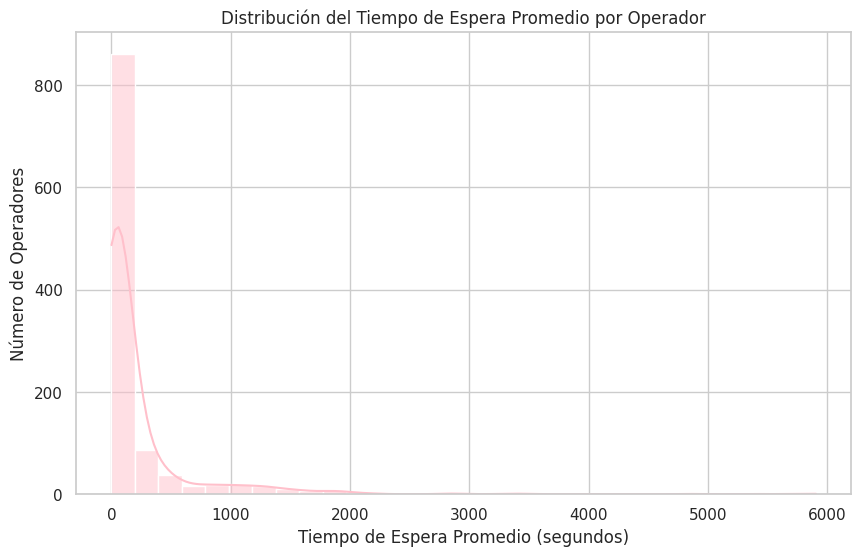

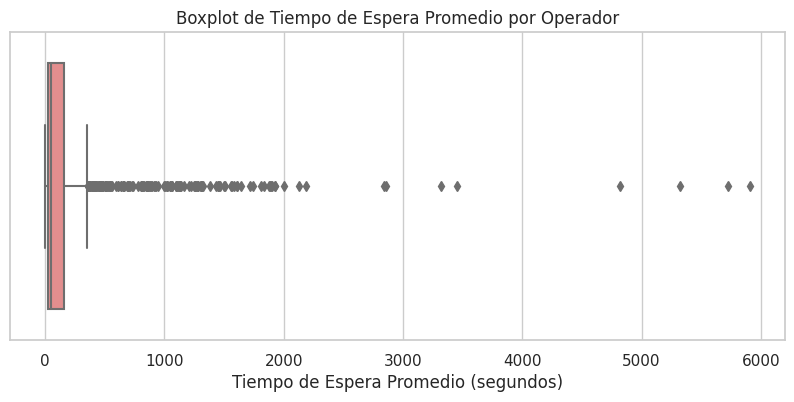

In [63]:
# Distribución del tiempo de espera promedio

# Configuración general de gráficos
sns.set(style="whitegrid")

# Histograma del tiempo de espera promedio
plt.figure(figsize=(10,6))
sns.histplot(operator_stats['avg_waiting_time'], bins=30, kde=True, color='pink')
plt.title("Distribución del Tiempo de Espera Promedio por Operador")
plt.xlabel("Tiempo de Espera Promedio (segundos)")
plt.ylabel("Número de Operadores")
plt.show()

# Boxplot para detectar outliers
plt.figure(figsize=(10,4))
sns.boxplot(x=operator_stats['avg_waiting_time'], color='lightcoral')
plt.title("Boxplot de Tiempo de Espera Promedio por Operador")
plt.xlabel("Tiempo de Espera Promedio (segundos)")
plt.show()

In [64]:
# Tabla de percentiles del tiempo de espera promedio
waiting_time_summary = operator_stats['avg_waiting_time'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
print("Resumen del Tiempo de Espera Promedio por Operador (segundos):")
print(waiting_time_summary)

Resumen del Tiempo de Espera Promedio por Operador (segundos):
count    1092.000000
mean      215.446189
std       504.915578
min         0.000000
25%        23.058824
50%        46.259878
75%       155.541011
90%       546.651471
95%      1127.366054
99%      1935.694780
max      5907.443038
Name: avg_waiting_time, dtype: float64


Interpretación

El 25% de los operadores registran un tiempo de espera promedio igual o menor a 23 segundos.

El 50% de los operadores presentan tiempos de espera promedio iguales o inferiores a 46 segundos.

Un 25% de los operadores supera los 156 segundos de espera promedio.

Alrededor del 10% muestra tiempos considerablemente altos, lo que podría indicar ineficiencia operativa.

Solo un 5% presenta demoras extremas en los tiempos de atención.

El 1% superior corresponde a operadores con muy bajo desempeño en cuanto a velocidad de respuesta.

Se detectaron casos atípicos con esperas de hasta 1.6 horas.

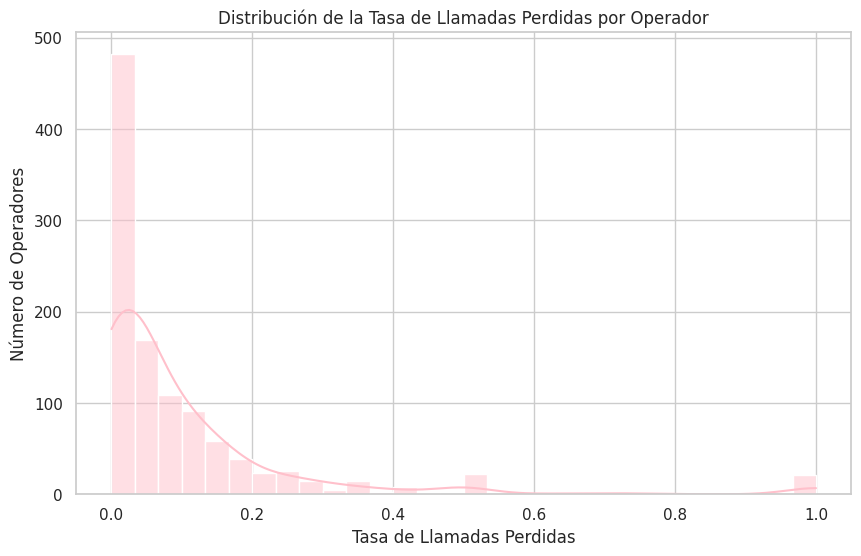

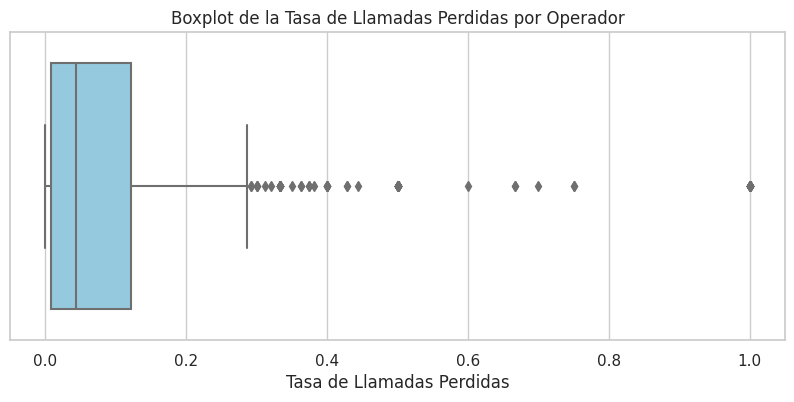

In [65]:
# Distribución de la tasa de llamadas perdidas

# Histograma de la tasa de llamadas perdidas
plt.figure(figsize=(10,6))
sns.histplot(operator_stats['missed_call_rate'], bins=30, kde=True, color='pink')
plt.title("Distribución de la Tasa de Llamadas Perdidas por Operador")
plt.xlabel("Tasa de Llamadas Perdidas")
plt.ylabel("Número de Operadores")
plt.show()

# Boxplot para detectar outliers
plt.figure(figsize=(10,4))
sns.boxplot(x=operator_stats['missed_call_rate'], color='skyblue')
plt.title("Boxplot de la Tasa de Llamadas Perdidas por Operador")
plt.xlabel("Tasa de Llamadas Perdidas")
plt.show()

In [66]:
# Tabla de percentiles de las llamadas perdidas 
missed_call_summary = operator_stats['missed_call_rate'].describe(percentiles=[0.25,0.5,0.75,0.9,0.95,0.99])
print("Resumen de la Tasa de Llamadas Perdidas por Operador:")
print(missed_call_summary)

Resumen de la Tasa de Llamadas Perdidas por Operador:
count    1092.000000
mean        0.100619
std         0.168800
min         0.000000
25%         0.008269
50%         0.043151
75%         0.121283
90%         0.250000
95%         0.400000
99%         1.000000
max         1.000000
Name: missed_call_rate, dtype: float64


Interpretación

El 25% de los operadores registra una tasa de pérdida menor al 1% de llamadas.

La mitad de los operadores pierde menos del 4.3% de las llamadas.

Un 25% presenta niveles superiores al 12% de llamadas perdidas.

Cerca del 10% de los operadores pierde más del 25% de sus llamadas.

El 5% superior muestra tasas significativamente altas de pérdida.

El 1% de los operadores pierde la totalidad de las llamadas asignadas, lo que representa un desempeño crítico.

In [67]:
# Identifiación de operadores ineficaces 

# Definimos umbrales a partir de percentiles
waiting_time_threshold = operator_stats['avg_waiting_time'].quantile(0.75)
missed_call_threshold = operator_stats['missed_call_rate'].quantile(0.75)

# Filtramos operadores ineficaces
inefficient_operators = operator_stats[
    (operator_stats['avg_waiting_time'] > waiting_time_threshold) &
    (operator_stats['missed_call_rate'] > missed_call_threshold)
].copy()

# Ordenar por ineficacia
inefficient_operators.sort_values(by=['avg_waiting_time','missed_call_rate'], ascending=False, inplace=True)

print(f"Total de operadores ineficaces: {inefficient_operators.shape[0]}")
inefficient_operators.head()

Total de operadores ineficaces: 0


,operator_id,total_calls,total_missed_calls,avg_waiting_time,total_out_calls,total_in_calls,missed_call_rate


El resultado “Total de operadores ineficaces: 0” indica que ningún operador supera simultáneamente ambos umbrales del percentil 75. Esto puede deberse a varias razones: algunos operadores podrían tener tiempos de espera elevados pero bajas tasas de llamadas perdidas, mientras que otros presentan el patrón opuesto —alta pérdida de llamadas pero tiempos de espera reducidos.

In [68]:
# Definimos umbrales a partir de percentiles
waiting_time_threshold = operator_stats['avg_waiting_time'].quantile(0.75)
missed_call_threshold = operator_stats['missed_call_rate'].quantile(0.75)

# Filtramos operadores ineficaces
inefficient_operators = operator_stats[
    (operator_stats['avg_waiting_time'] > waiting_time_threshold) |
    (operator_stats['missed_call_rate'] > missed_call_threshold)
].copy()

# Ordenar por ineficacia
inefficient_operators.sort_values(by=['avg_waiting_time','missed_call_rate'], ascending=False, inplace=True)

print(f"Total de operadores ineficaces: {inefficient_operators.shape[0]}")
inefficient_operators.head(10)

Total de operadores ineficaces: 546


,operator_id,total_calls,total_missed_calls,avg_waiting_time,total_out_calls,total_in_calls,missed_call_rate
551,925922.0,22210,33,5907.443038,21754,456,0.001486
29,885890.0,66016,110,5727.133574,64653,1363,0.001666
583,929428.0,24572,35,5325.342857,24572,0,0.001424
28,885876.0,66049,135,4816.241379,64897,1152,0.002044
317,908640.0,16699,24,3456.461538,16699,0,0.001437
582,929426.0,12041,35,3316.558824,12041,0,0.002907
843,945278.0,4314,25,2858.479167,4314,0,0.005795
448,919364.0,5096,23,2841.465116,5096,0,0.004513
847,945286.0,7919,37,2185.774648,7919,0,0.004672
870,945904.0,4080,19,2128.657895,4080,0,0.004657


Interpretación

Algunos operadores presentan tiempos de espera excepcionalmente bajos, incluso cuando su tasa de llamadas perdidas también es reducida.

En contraste, otros operadores muestran porcentajes elevados de llamadas perdidas, a pesar de mantener tiempos de espera promedio bajos.

Interpretación

Algunos operadores presentan tiempos de espera excepcionalmente bajos, incluso cuando su tasa de llamadas perdidas también es reducida.

En contraste, otros operadores muestran porcentajes elevados de llamadas perdidas, a pesar de mantener tiempos de espera promedio bajos.

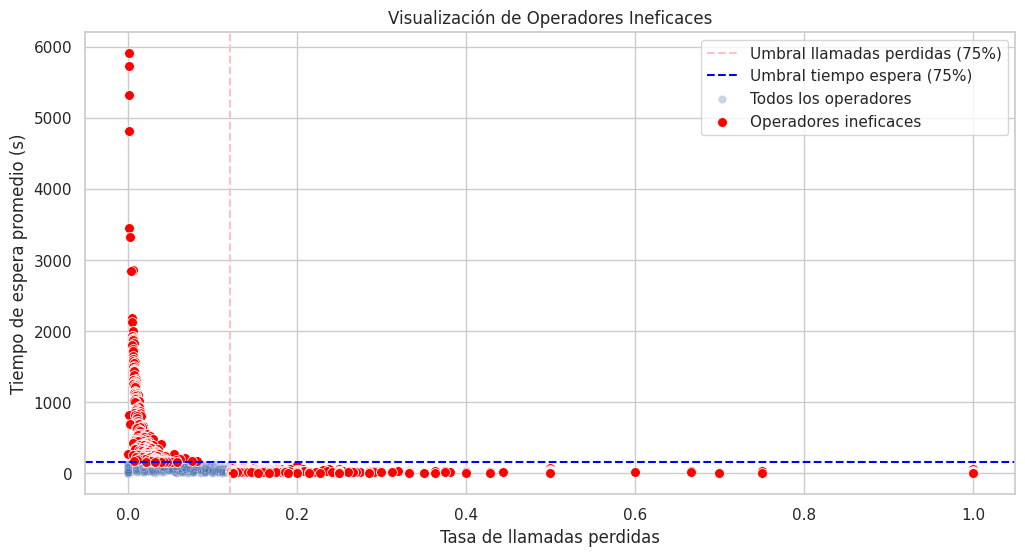

In [69]:
plt.figure(figsize=(12,6))

# Todos los operadores
sns.scatterplot(
    data=operator_stats, 
    x='missed_call_rate', 
    y='avg_waiting_time',
    alpha=0.3, 
    label='Todos los operadores'
)

# Operadores ineficaces
sns.scatterplot(
    data=inefficient_operators, 
    x='missed_call_rate', 
    y='avg_waiting_time',
    color='red', 
    s=50,
    label='Operadores ineficaces'
)

# Líneas de umbral
plt.axvline(x=missed_call_threshold, color='pink', linestyle='--', label='Umbral llamadas perdidas (75%)')
plt.axhline(y=waiting_time_threshold, color='blue', linestyle='--', label='Umbral tiempo espera (75%)')

plt.title('Visualización de Operadores Ineficaces')
plt.xlabel('Tasa de llamadas perdidas')
plt.ylabel('Tiempo de espera promedio (s)')
plt.legend()
plt.show()

Interpretación

Cuadrante superior derecho: corresponde a los operadores con altas tasas de llamadas perdidas y largos tiempos de espera, considerados críticos en desempeño.

Puntos rojos dispersos: representan a los operadores que destacan negativamente en alguno de los dos indicadores.

Líneas de umbral: permiten visualizar los criterios utilizados para definir la ineficacia operativa.

Queda por analizar si la falta de llamadas activas por parte de un operador —cuando forma parte de sus funciones— también refleja un bajo rendimiento.



In [70]:
# Definimos el umbral para llamadas salientes bajas 
low_out_calls_threshold = operator_stats['total_out_calls'].quantile(0.25)
print(f"Umbral de pocas llamadas salientes (percentil 25): {low_out_calls_threshold}")

Umbral de pocas llamadas salientes (percentil 25): 2.0


Se filtran operadores ineficaces considerando tres criterios

Tiempo de espera alto
Tasa de llamadas perdidas alta
Pocas llamadas salientes


In [71]:
# Filtramos operadores ineficaces con los tres criterios
inefficient_operators_refined = operator_stats[
    (operator_stats['avg_waiting_time'] > waiting_time_threshold) |
    (operator_stats['missed_call_rate'] > missed_call_threshold) |
    (operator_stats['total_out_calls'] < low_out_calls_threshold)
].copy()

# Ordenamos por gravedad
inefficient_operators_refined.sort_values(
    by=['avg_waiting_time','missed_call_rate','total_out_calls'], 
    ascending=[False, False, True], 
    inplace=True
)

print(f"Total de operadores ineficaces (refinado): {inefficient_operators_refined.shape[0]}")
inefficient_operators_refined.head(10)

Total de operadores ineficaces (refinado): 771


,operator_id,total_calls,total_missed_calls,avg_waiting_time,total_out_calls,total_in_calls,missed_call_rate
551,925922.0,22210,33,5907.443038,21754,456,0.001486
29,885890.0,66016,110,5727.133574,64653,1363,0.001666
583,929428.0,24572,35,5325.342857,24572,0,0.001424
28,885876.0,66049,135,4816.241379,64897,1152,0.002044
317,908640.0,16699,24,3456.461538,16699,0,0.001437
582,929426.0,12041,35,3316.558824,12041,0,0.002907
843,945278.0,4314,25,2858.479167,4314,0,0.005795
448,919364.0,5096,23,2841.465116,5096,0,0.004513
847,945286.0,7919,37,2185.774648,7919,0,0.004672
870,945904.0,4080,19,2128.657895,4080,0,0.004657


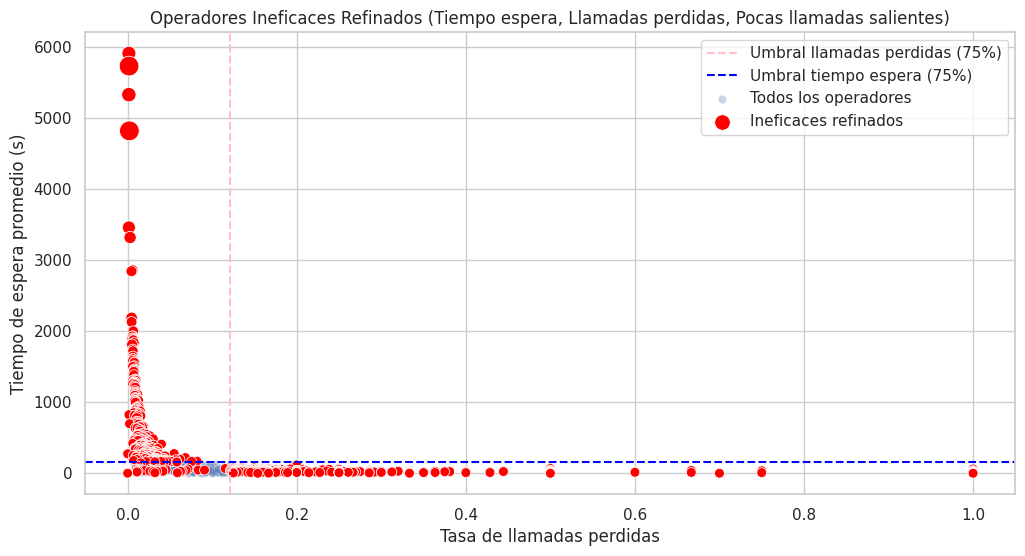

In [72]:
plt.figure(figsize=(12,6))

# Todos los operadores
sns.scatterplot(
    data=operator_stats, 
    x='missed_call_rate', 
    y='avg_waiting_time',
    alpha=0.3, 
    label='Todos los operadores'
)

# Operadores ineficaces refinados
sns.scatterplot(
    data=inefficient_operators_refined, 
    x='missed_call_rate', 
    y='avg_waiting_time',
    size='total_out_calls',
    sizes=(50, 200),  # puntos más pequeños = pocas llamadas
    color='red', 
    legend=False,
    label='Ineficaces refinados'
)

# Líneas de umbral
plt.axvline(x=missed_call_threshold, color='pink', linestyle='--', label='Umbral llamadas perdidas (75%)')
plt.axhline(y=waiting_time_threshold, color='blue', linestyle='--', label='Umbral tiempo espera (75%)')

plt.title('Operadores Ineficaces Refinados (Tiempo espera, Llamadas perdidas, Pocas llamadas salientes)')
plt.xlabel('Tasa de llamadas perdidas')
plt.ylabel('Tiempo de espera promedio (s)')
plt.legend()
plt.show()

4. ANÁLISIS COMPARATIVO Y PRUEBAS ESTADÍSTICAS

El siguiente paso es comprobar si las diferencias entre los operadores "ineficaces" y los "eficaces" son estadísticamente significativas.

In [73]:
# Creamos una columna que marque si el operador es ineficaz
operator_stats['ineficaz'] = operator_stats['operator_id'].isin(inefficient_operators_refined['operator_id'])

# Verificamos distribución de grupos
operator_stats['ineficaz'].value_counts()

True     771
False    321
Name: ineficaz, dtype: int64

In [74]:
# Comparación de métricas entre operadores eficaces e ineficaces
comparacion = operator_stats.groupby('ineficaz')[['avg_waiting_time', 'missed_call_rate', 'total_out_calls']].mean().round(2)
display(comparacion)

,avg_waiting_time,missed_call_rate,total_out_calls
ineficaz,,,
False,66.4,0.07,254.22
True,277.5,0.12,762.30


Hasta ahora podemos ver como los operadores definidos como "ineficaces" muestran tiempo de espera y tasas dfe llamadas perdidas mayores. El número de llamadas salientes podria estar relacionado con intentos repetidos o mala gestión en el flujo de llamadas

In [75]:
eficaces = operator_stats[operator_stats['ineficaz'] == False]
ineficaces = operator_stats[operator_stats['ineficaz'] == True]

# Pruebas Mann–Whitney
for col in ['avg_waiting_time', 'missed_call_rate', 'total_out_calls']:
    stat, p = mannwhitneyu(eficaces[col], ineficaces[col], alternative='two-sided')
    print(f"{col} > Estadístico U: {stat:.2f}, p-valor: {p:.5f}")

avg_waiting_time > Estadístico U: 124592.50, p-valor: 0.85849
missed_call_rate > Estadístico U: 144067.00, p-valor: 0.00002
total_out_calls > Estadístico U: 154119.50, p-valor: 0.00000


Entonces:

avg_waiting_time: No hay evidencia estadística de que el tiempo promedio de espera difiera significativamente entre operadores "eficaces" e "ineficaces".
missed_call_rate: La tasa de llamadas perdidas SI es significativamente mayor en los operadores "ineficaces". Podemos confirmar que si desempeño en atención es peor.
total_out_calls: La tasa de llamadas salientes también es significativa (aunque no podemos confirmar que + llamadas implica mejor desempeño)


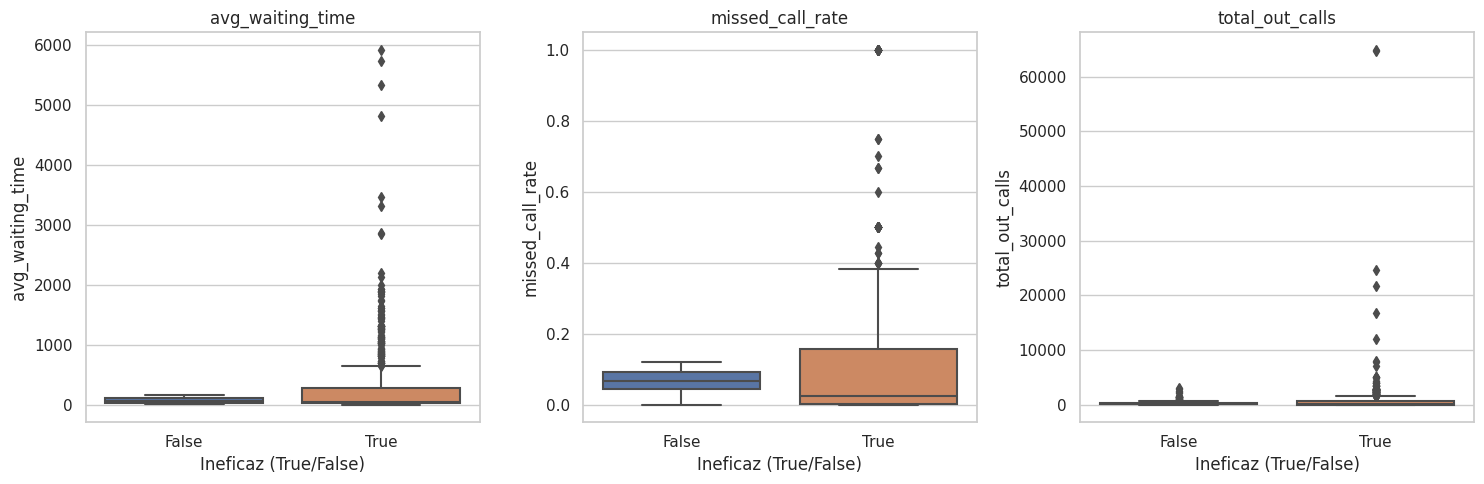

In [76]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['avg_waiting_time', 'missed_call_rate', 'total_out_calls']

for ax, col in zip(axes, metrics):
    sns.boxplot(data=operator_stats, x='ineficaz', y=col, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("Ineficaz (True/False)")

plt.tight_layout()
plt.show()

5. CONCLUSIONES

El análisis exploratorio permitió identificar los siguientes hallazgos clave:

El tiempo de espera promedio por operador presenta una distribución altamente sesgada, con valores máximos que superan los 5,000 segundos.

La tasa promedio de llamadas perdidas es del 10%, aunque algunos operadores alcanzan valores extremos de hasta 100%.

El volumen de llamadas salientes muestra una alta desigualdad, concentrándose en un número reducido de operadores con mayor carga de trabajo.

Para evaluar la eficiencia operativa, se definieron criterios basados en los percentiles 75 de tiempo de espera y tasa de llamadas perdidas, y en el percentil 25 del volumen de llamadas salientes.
Bajo estos parámetros, se identificaron 771 operadores ineficaces, lo que representa el 71% del total analizado.

Los resultados de las pruebas estadísticas de Mann–Whitney revelaron que:

No existen diferencias significativas en el tiempo de espera entre operadores eficaces e ineficaces (p = 0.858).

Sí existen diferencias significativas en la tasa de llamadas perdidas (p = 0.00002) y en el volumen de llamadas salientes (p < 0.0001).

Estos hallazgos sugieren que la ineficiencia está más relacionada con la gestión deficiente de llamadas y las altas tasas de abandono, que con la duración del tiempo de espera.

6. RECOMENDACIONES

Reducir la tasa de llamadas perdidas

Es el indicador más asociado con la ineficiencia.

Se recomienda reforzar la capacitación en atención simultánea, la priorización de llamadas y el uso eficiente de los tiempos de respuesta.

Optimizar la gestión de llamadas salientes

Algunos operadores presentan volúmenes muy bajos de llamadas salientes, lo que puede reflejar falta de proactividad o sobrecarga en llamadas entrantes.

Se sugiere revisar la distribución de tareas y establecer objetivos mínimos de llamadas salientes.

Revisar el tiempo de espera promedio

Aunque no se detectaron diferencias significativas entre grupos, el promedio de los operadores ineficaces (277.5 segundos) sigue siendo elevado.

Se recomienda analizar los casos atípicos y la variabilidad individual para identificar posibles cuellos de botella.

Reevaluar los criterios de desempeño

Ajustar los umbrales de ineficiencia (por ejemplo, utilizar el percentil 80 en lugar del 75) podría ayudar a enfocar las acciones en los casos de desempeño más crítico, evitando intervenciones innecesarias.

Implementar un monitoreo continuo

Desarrollar dashboards en tiempo real que muestren la evolución de los indicadores por operador.

Esto permitiría detectar tempranamente desviaciones, aplicar acciones correctivas oportunas y mejorar la toma de decisiones basada en datos.

7. FUENTES Y REFERENCIAS

AmplifAI — “Call Center Productivity: Ultimate Guide to Metrics, and Strategies (2025)”

TCN — “What Inefficiencies Can BI Uncover in Your Call Center?”

McKinsey & Company — “Why your call center is only getting noisier”

McKinney, W. (2010). Data Structures for Statistical Computing in Python. Proceedings of the 9th 
Python in Science Conference, 51–56.

Harris, C. R., Millman, K. J., van der Walt, S. J., et al. (2020). Array programming with NumPy. Nature, 585, 357–362.

Hunter, J. D. (2007). Matplotlib: A 2D Graphics Environment. Computing in Science & Engineering, 9(3), 90–95.

Waskom, M. L. (2021). Seaborn: Statistical Data Visualization. Journal of Open Source Software, 6(60), 3021.

Virtanen, P., Gommers, R., Oliphant, T. E., et al. (2020). SciPy 1.0: Fundamental Algorithms for Scientific Computing in Python. Nature Methods, 17, 261–272.

8. PRESENTACIÓN PDF

https://drive.google.com/file/d/1NmS_9WgcE89Q0jeXnA9S81rt6NmVN4d1/view?usp=sharing

En esta presentación se incluyen las observaciones, conclusiones y recomendaciones generales de este proyecto. 

9. DASHBOARD

https://public.tableau.com/app/profile/dalia.baca/viz/CallMeMaybeCallCenterDashboardDaliaGB/CallMeMaybe?publish=yes

El primer histograma presenta la duración de las llamadas.
El segundo es un gráfico circular donde se muestra la participación de las llamadas internas y externas. 
Cabe mencionar que en l dahsboard existen filtros para la duración y dirección de las llamadas. 